# Tarea 2

### Cuerpo Docente

- Profesores: [Andrés Abeliuk](https://aabeliuk.github.io/), [Fabián Villena](https://villena.cl/).
- Profesor Auxiliar: Martín Paredes

### Instrucciones generales

- Grupos de máximo 4 personas.
- Esta prohibido compartir las respuestas con otros grupos.
- Indicios de copia serán penalizados con la nota mínima.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente, si utiliza material extra debe citarlo.


### Integrantes

> Manuel Bórquez Basáez [mbb]

## Contexto

El discurso de odio es cualquier expresión que promueva o incite a la discriminación, la hostilidad o la violencia hacia una persona o grupo de personas en una relación asimétrica de poder, tal como la raza, la etnia, el género, la orientación sexual, la religión, la nacionalidad, una discapacidad u otra característica similar.

En cambio, la incivilidad se refiere a cualquier comportamiento o actitud que rompe las normas de respeto, cortesía y consideración en la interacción entre personas. Esta puede manifestarse de diversas formas, tal como insultos, ataques personales, sarcasmo, desprecio, entre otras.

En esta tarea tendrán a su disposición un dataset de textos con las etiquetas `odio`, `incivilidad` o `normal`. La mayor parte de los datos se encuentra en español de Chile. Con estos datos, deberán entrenar un modelo que sea capaz de predecir la etiqueta de un texto dado.

El corpus para esta tarea se compone de 3 datasets:  
- [Multilingual Resources for Offensive Language Detection de Arango et al. (2022)](https://aclanthology.org/2022.woah-1.pdf#page=136)
- [Dataton UTFSM No To Hate (2022)](http://dataton.inf.utfsm.cl/)
- Datos generados usando la [API de GPT3 (modelo DaVinci 03)](https://platform.openai.com/docs/models/gpt-3).

Agradecimientos a los autores por compartir los datos y a David Miranda, Fabián Diaz, Santiago Maass y Jorge Ortiz por revisar y reetiquetar los datos en el contexto del curso "Taller de Desarrollo de Proyectos de IA" (CC6409), Departamento de Ciencias de la Computación, Universidad de Chile.

Los datos solo pueden ser usados con fines de investigación y docencia. Está prohibida la difusión externa.


## Enunciado

**Tarea a resolver**:

Para esta tarea 2, buscaremos desarrollar un *benchmark* sobre una tarea de clasificación de NLP. Un benchmark es básicamente utilizar diferentes técnicas para resolver una misma tarea específica, en este caso seguiremos buscando alternativas para resolver el problema de clasificación de la tarea 1. Particularmente, se le pide:

- Implementar una arquitectura en RNN utilizando PyTorch.
- Utilizar transformers para revolver el problema de clasificación, en especifico utilizar BETO.
- Utilizar algún LLM utilizando Zero y Few short learning para resolver el problema de clasificación.


## Instrucciones

### 1. Configuraciones y Exploración del Dataset

#### 1.1. Cargar el Dataset

En esta sección, cargaremos el dataset desde el repositorio del módulo. Para ello ejecute las siguientes líneas:

```python
# imports
import pandas as 

# Dataset.
dataset_df = pd.read_csv("https://raw.githubusercontent.com/dccuchile/CC6205/master/assignments/new/assignment_1/train/train.tsv", sep="\t")
```

#### 1.2. Analizar los Datos

En esta sección analizaremos el balance de los datos. Para ello se imprime la cantidad de tweets de cada dataset agrupads por la intensidad de sentimiento.

```python
dataset_df.sample(5)
dataset_df["clase"].value_counts()
target_classes = list(dataset_df['clase'].unique())
target_classes
```

#### 1.3. Instalar Librerias

Puede usar esta celda para instalar las librerías que estime necesario.

```python
%%capture
```

#### 1.4. Importar Librerías

En esta sección, importamos la liberías necesarias para el correcto desarrollo de esta tarea. Puede utilizar otras librerías que no se en encuentran aquí, pero debe citar su fuente.

```python
!pip uninstall torch torchvision torchaudio

!pip install torch==2.3.0 --index-url https://download.pytorch.org/whl/cpu
!pip uninstall scipy
!pip install scipy==1.11.4
!pip install torchtext
!pip install scikit-plot

import nltk
import numpy as np
from nltk import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin

# importe aquí sus clasificadores
import matplotlib.pyplot as plt

# word2vec
from gensim.models import Word2Vec, KeyedVectors
from gensim.models.phrases import Phrases, Phraser

# Pytorch imports
import torch
from torchtext.data import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torch.utils.data import DataLoader
from torchtext.data.functional import to_map_style_dataset
from torch import nn
from torch.nn import functional as F
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import gc
from torch.optim import Adam
```

### 2. Clasificador RNN

#### 2.1. Crear un Clasificador basado en RNN

En esta parte de le pide definir un clasificador utilizando `PyTorch` con alguna arquitectura en Redes Recurrentes. Para ello debe realizar todos los pasos vistos en el tutorial 5, por lo que se recomienda revisarlo. Importante, no puede replicar ningún ejemplo de los del tutorial 5, debe proponer sus propias arquitecturas. Se le recomienda leer como utilizar variaciones de la RNN, como la LSTM o GRU en `Pytorch`.

Para completa esta parte deberá replicar el flujo de trabajo de como utilizar `PyTorch`. Esta esctrictamente prohibido utilizar variaciones que resuelvan directamente este problema, como `PyTorch Lightning` o `TensorFlow`. Los pasos a completar son los siguientes:

#### 2.2. Cargar el Dataset

Definir el vocabulario.

#### 2.3. Cargar el `DataLoader`

Recuerde que podría necesitar una función intermedia para procesar cada batch durante el entrenamiento, pero no es obligatorio hacerlo.

#### 2.4. Definir la Red Recurrente

Recuerde que debe difirnir los hyperparametros que estime conveniente.

```python
class RNNClassifier(nn.Module):
    def __init__(self):
        super(RNNClassifier, self).__init__()
        pass
    def forward(self, X_batch):
        pass
```

#### 2.5. Funciones de Entrenamiento y Evaluación

Para esta parte, puede utilizar las funciones vista en el tutorial directamente. Pero es su reponsabilidad ajustarlas a su código.

```python
def CalcValLossAndAccuracy(model, loss_fn, val_loader):
    with torch.no_grad():
        Y_shuffled, Y_preds, losses = [],[],[]
        for X, Y in val_loader:
            preds = model(X)
            loss = loss_fn(preds, Y)
            losses.append(loss.item())

            Y_shuffled.append(Y)
            Y_preds.append(preds.argmax(dim=-1))

        Y_shuffled = torch.cat(Y_shuffled)
        Y_preds = torch.cat(Y_preds)

        print("Valid Loss : {:.3f}".format(torch.tensor(losses).mean()))
        print("Valid Acc  : {:.3f}".format(accuracy_score(Y_shuffled.detach().numpy(), Y_preds.detach().numpy())))

def TrainModel(model, loss_fn, optimizer, train_loader, val_loader, epochs=10):
    for i in range(1, epochs+1):
        losses = []
        for X, Y in tqdm(train_loader):
            Y_preds = model(X)

            loss = loss_fn(Y_preds, Y)
            losses.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print("Train Loss : {:.3f}".format(torch.tensor(losses).mean()))
        CalcValLossAndAccuracy(model, loss_fn, val_loader)

def MakePredictions(model, loader):
    Y_shuffled, Y_preds = [], []
    for X, Y in loader:
        preds = model(X)
        Y_preds.append(preds)
        Y_shuffled.append(Y)
    gc.collect()
    Y_preds, Y_shuffled = torch.cat(Y_preds), torch.cat(Y_shuffled)

    return Y_shuffled.detach().numpy(), F.softmax(Y_preds, dim=-1).argmax(dim=-1).detach().numpy()
```

#### 2.6. Entrenamiento del Modelo

Ejecute el entrenamiento de su modelo propuesto.

```python
epochs = ...
learning_rate = ...

loss_fn = nn.CrossEntropyLoss()
rnn_classifier = RNNClassifier()
optimizer = Adam(rnn_classifier.parameters(), lr=learning_rate)

TrainModel(rnn_classifier, loss_fn, optimizer, train_loader, test_loader, epochs)
```

#### 2.7. Evaluacion del Modelo

Ejecute la evaluación de su modelo, y genere un reporte de evaluación similar al de la pregunta anterior.

```python
Y_actual, Y_preds = MakePredictions(rnn_classifier, test_loader)

print("Test Accuracy : {}".format(accuracy_score(Y_actual, Y_preds)))
print("\nClassification Report : ")
print(classification_report(Y_actual, Y_preds, target_names=target_classes))
print("\nConfusion Matrix : ")
print(confusion_matrix(Y_actual, Y_preds))
```

Finalmente, análice sus resultados, ¿Porqué cree que obtuvo esos resultados?, ¿Es mejor que sólo utilizar Word Embeddings, porque?. Justique.

### 3. Transformers BERT

Para esta tarea se le piden crear una representación de texto usando la arquitectura basada en transformers, BERT:

```python
!pip install transformers
```

#### 3.1. Import BETO

Para esto debe importar el tokenizador y el modelo BETO.

```python
from transformers import AutoTokenizer, AutoModelForMaskedLM
```

#### 3.2. Ejemplo de Extracción de Features

Luego, debe cargar los modelos pre-entrenados:

```python
tokenizer = AutoTokenizer.from_pretrained('dccuchile/bert-base-spanish-wwm-uncased')
model = AutoModelForMaskedLM.from_pretrained('dccuchile/bert-base-spanish-wwm-uncased', output_hidden_states=True)
```

Una vez cargado BETO, debe utilizarlo para extraer los embeddings asociados a la texto de su corpus. Se espera que usted realice lo siguiente:

Tokenizamos el texto para extraer los ids a cada palabra en el vocabulario interno de BETO, se recomienda utilizar el padding, trunctation, y max_length para considerar oraciones de diferentes tamaños.

Luego, debe verificar si cada uno de los ids extraídos se encuentran en la misma máquina donde fue cargado el modelo (CPU o GPU), se recomienda dejar todo en GPU.

```python
# oración
sentence = "Hola, que tal? me gusta mucho el curso de NLP"

# extraemos los ids de los tokens, se recomienda definir los valores de las variables:
#  padding, truncation, max_length debido a que las secuencia de texto puede tener diferentes largos
inputs = tokenizer(sentence, padding=True, truncation=True, return_tensors="pt", max_length=512)
# revisamos si cada de los ids, se encuentran en la misma máquina que el modelo (GPU o CPU)
inputs = {k: v.to(model.device) for k, v in inputs.items()}
inputs
```
Una vez, extraídos los ids, usted debe obtener los estados ocultos de las ultimas capas de BETO.

```python
# Extraemos la features
outputs = model(**inputs)

# ahora `outputs` tendrá el atributo `hidden_states`
hidden_states = outputs.hidden_states
```
Finalmente, debe guardar los embeddings en CPU los embeddings del token [CLS] que será usados en la clasificación del análisis de sentimientos.
```python
with torch.no_grad():
# Seleccionamos la última capa y obtenemos el primer token ([CLS]) para cada ejemplo
# Estos son los embeddings que normalmente se usan para tareas de clasificación.
  cls_embeddings = hidden_states[-1][:, 0, :].cpu().numpy()
```

#### 3.3. Extraer Features de todo el Dataset

Considerando lo anterior, usted debe implementar la función `get_beto_features_in_batches` para extraer los features de BETO (los estados ocultos y los embeddings del token [CLS]).

Esta función recibe dos parámetros, el texto a vectorizar y un tamaño de batch, debido a que es extramadamente recomendable a que procesen el texto por lotes, ya que si cargan todos el modelo se les agotará la memoria RAM.

```python
# Función para procesar los textos en lotes y obtener las características de BETO

def get_beto_features_in_batches(texts, batch_size):

  pass
```
Ahora extraíga los features, un punto importante es que la extracción de features podría tomar alrededor de una a dos horas dependiendo del tamaño del batch que utilicen.
```python
train_embs = get_beto_features_in_batches(..., ...)
```

#### 3.4. Clasificación

Una vez extraído los features de BETO, realice la clasificación de los embeddings obtenidos. Debe implementar dos clasificadores a su elección.

#### 3.5. Reporte de evaluación

Una vez realizada la clasificación, realice el reporte de clasificación y el análsis de la matriz confusión para ambos clasificadores.

Recuerde que para hacer esto, debe extraer los features del dataset de testing.

Finalmente, que puede decir de los resultados obtenidos. ¿Se diferencia de los resultados obtenidos de la red RNN? ¿A que se debe esto? Justifique

### 4. Large Language Model (LLM)

#### 4.1. Zero Shot Learning

Utilizando la técnica de zero shot learning, utilice la API de `openai` para clasificar el texto del dataset.
Además, genere el reporte de clasificación usando `scikit-learn` como en las preguntas anteriores.
Recuerde solicitar al profesor auxiliar el TOKEN para hacer consultas al LLM.

#### 4.2. Few Shot Learning

Utilizando la técnica de few shot learning, utilice la API de `openai` para clasificar el texto del dataset.
Además, genere el reporte de clasificación usando `scikit-learn` como en las preguntas anteriores.
Recuerde solicitar al profesor auxiliar el TOKEN para hacer consultas al LLM.


## Implementación

**Índice**:

- 1. Configuraciones y Exploración del Dataset
  - 1.1. Cargar el Dataset
  - 1.2. Analizar los Datos
  - 1.3. Instalar Librerías
  - 1.4. Importar Librerías
- 2. Clasificador Basado en RNN
  - 2.1. Preparar Particiones Dataset
  - 2.2. Definir Vocabulario
  - 2.3. Cargar el `DataLoader`
  - 2.4. Definir la Red Recurrente
  - 2.5. Funciones de Entrenamiento y Evaluación
  - 2.6. Entrenamiento del Modelo
  - 2.7. Evaluación del Modelo
- 3. Transformers BERT
  - 3.1. Import BETO
  - 3.2. Ejemplo de Extracción de Features
  - 3.3. Extraer Features de todo el Dataset
  - 3.4. Clasificación
  - 3.5. Reporte de Evaluación
- 4. Large Language Model (LLM)
  - 4.1. Zero Shot Learning
  - 4.2. Few Shot Learning

### 1. Configuraciones y Exploración del Dataset

#### 1.1. Cargar el Dataset

In [ ]:
# imports
import matplotlib.pyplot as plt
import pandas as pd
import urllib.request
from pathlib import Path
from pprint import pprint
import json
import hashlib


In [2]:
# carpeta data
DIR_DATA = Path("data")
DIR_DATA.mkdir(parents=True, exist_ok=True)
DIR_RAW_DATA = Path(DIR_DATA / "raw")
DIR_RAW_DATA.mkdir(parents=True, exist_ok=True)

# carpeta salida
DIR_OUTPUTS = Path("outputs")
DIR_OUTPUTS.mkdir(parents=True, exist_ok=True)

# carpeta checkpoints de modelos
DIR_CHECKP = Path(DIR_OUTPUTS / "model_checkpoints")
DIR_CHECKP.mkdir(parents=True, exist_ok=True)

# carpeta historias de entrenamiento
DIR_HIST = Path(DIR_OUTPUTS / "training_histories")
DIR_HIST.mkdir(parents=True, exist_ok=True)

# parquets
DIR_PARQUETS = Path(DIR_OUTPUTS / "parquets")
DIR_PARQUETS.mkdir(parents=True, exist_ok=True)

# archivo train.tsv
ARCHIVO_NOM = "train.tsv"
ARCHIVO_URL = "https://raw.githubusercontent.com/dccuchile/CC6205/master/assignments/new/assignment_1/train/train.tsv"
PATH_TRAINTSV = Path(DIR_RAW_DATA, ARCHIVO_NOM)


In [3]:
# descarga dataset en caso de no existir
if PATH_TRAINTSV.exists():
    print(f"[INFO] Archivo ya disponible en {PATH_TRAINTSV}")
else:
    print(f"[INFO] Descargando {ARCHIVO_NOM}")
    try:
        urllib.request.urlretrieve(ARCHIVO_URL, PATH_TRAINTSV)
        print(f"- Descarga de archivo {ARCHIVO_NOM} completada.")
    except Exception as e:
        print(f"[ERROR] Error al descargar archivo {ARCHIVO_NOM}: {e}")


[INFO] Archivo ya disponible en data/raw/train.tsv


In [4]:
dataset_df = pd.read_csv(PATH_TRAINTSV, sep="\t")
print("[INFO] datos generales del dataset:")
print(" - type:", type(dataset_df))
print(" - shape:", dataset_df.shape)
print(" - columnas:", list(dataset_df.columns))
print("\n - tipos de datos:")
print(dataset_df.dtypes)
print("\n - valores nulos por columna:")
print(dataset_df.isnull().sum())


[INFO] datos generales del dataset:
 - type: <class 'pandas.core.frame.DataFrame'>
 - shape: (12214, 3)
 - columnas: ['id', 'texto', 'clase']

 - tipos de datos:
id        int64
texto    object
clase    object
dtype: object

 - valores nulos por columna:
id       0
texto    0
clase    0
dtype: int64


#### 1.2. Analizar los datos

**clases del dataset**:

In [5]:
target_classes = list(dataset_df['clase'].unique())
target_classes


['normal', 'incivilidad', 'odio']

**muestra de 5 ejemplos**:

In [6]:
dataset_df.sample(5)


,id,texto,clase
7006,5663,"De la manito de la derecha como siempre, amari...",incivilidad
11740,15234,@user @user Se arrepintió de ser perra de Petro?,incivilidad
7503,9887,Favor difundir: @user haciendo pasar a niñxs a...,incivilidad
6771,14690,@user @user @user @user @user No se quien será...,normal
5639,5778,No nos metan a todos los que votamos en Provi/...,incivilidad


**contador de ejemplos por clases**:

In [7]:
dataset_df["clase"].value_counts()


clase
incivilidad    5424
normal         4280
odio           2510
Name: count, dtype: int64

**notas**:
- *incivilidad*: 5.424 ejemplos, 
  - domina del conjunto y casi duplica a odio
  - esto podría sesgar modelos hacia esa etiqueta/clases
- *normal*: 4.280
  - cercana a incivilidad
  - podría convenir analizar métricas por clase (F1 macro) para no sobre‑optimizar la mayoría
- *odio*: 2.510
  - clase minoritaria

**visualización de distribución de clases**:

[INFO] Clases presentes:


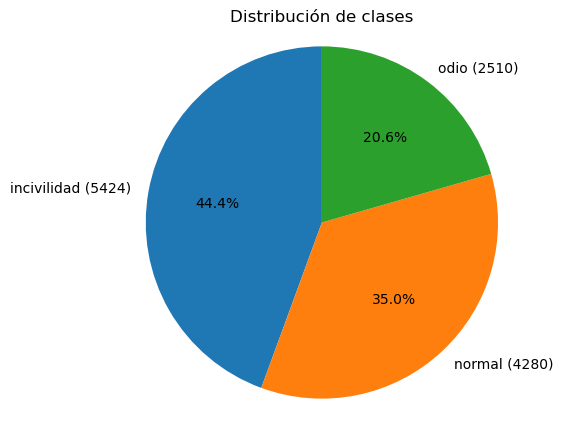

In [8]:
# valores posibles y frecuencia de la columna 'clase'
print("[INFO] Clases presentes:")
conteos = dataset_df["clase"].value_counts()
labels = [f"{clase} ({conteo})" for clase, conteo in conteos.items()]
plt.figure(figsize=(5, 5))
plt.pie(
    conteos,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribución de clases")
plt.axis("equal")
plt.show()


#### 1.3. Instalar Librerías

La instalación de las librerías se hace por medio de yml y creación de environment de conda (ver README.md):

In [9]:
!cat environment.yml


name: mbb-cc66q-1-assignment-2
channels:
  - conda-forge
  - nodefaults
dependencies:
  - python=3.11
  - pip
  - jupyterlab>=4
  - ipykernel
  - numpy>=1.26
  - pandas>=2.0
  - matplotlib>=3.8
  - scikit-learn>=1.4
  - nltk>=3.8
  - gensim>=4.3
  - tqdm>=4.66
  - pip:
      - torch==2.3.0
      - torchtext==0.18.0
      - transformers>=4.47
      - datasets>=2.19
      - evaluate>=0.4
      - accelerate>=0.33
      - sentencepiece>=0.2
      - scipy==1.11.4
      - scikit-plot
      - wordcloud>=1.9
      - ipywidgets
      - safetensors>=0.4

#### 1.4. Importar librerias

In [10]:
import nltk
import numpy as np
import math
import time

from nltk import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.base import BaseEstimator, TransformerMixin

# importe aquí sus clasificadores


# word2vec
from gensim.models import Word2Vec, KeyedVectors
from gensim.models.phrases import Phrases, Phraser

# Pytorch imports
import torch
import torchtext
torchtext.disable_torchtext_deprecation_warning()

from torchtext.data import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torch.utils.data import Dataset
from functools import partial

from torch.utils.data import DataLoader
from torchtext.data.functional import to_map_style_dataset

from torch import nn
from torch.nn import functional as F

from tqdm import tqdm
from sklearn.metrics import accuracy_score
import gc

from torch.optim import Adam


### 2. Clasificador Basado en RNN

**Instrucciones principales**:
- definir un clasificador utilizando `PyTorch` con alguna arquitectura en Redes Recurrentes
- realizar todos los pasos vistos en el tutorial 5
- no puede replicar ningún ejemplo de los del tutorial 5, 
- proponer propias arquitecturas
- estudiar variaciones de la RNN, como la LSTM o GRU en `Pytorch`
- replicar el flujo de trabajo de como utilizar `PyTorch`
- esta esctrictamente prohibido utilizar variaciones que resuelvan directamente este problema, como `PyTorch Lightning` o `TensorFlow`

#### 2.1. Preparar Particiones Dataset

**constantes y reproducibilidad**:

In [ ]:
SEED = 42
import random
torch.manual_seed(SEED)
np.random.seed(SEED)
PROPORCION_VALIDACION=0.2
#BATCH_SIZE = 1024 
BATCH_SIZE=64


In [12]:
dispositivo = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"[INFO] Usando dispositivo: {dispositivo}")


[INFO] Usando dispositivo: mps


**separar dataset para entrenamiento y validación**:

In [13]:
# cargar y preparar dataset
train_df, val_df = train_test_split(
        dataset_df,
        test_size=PROPORCION_VALIDACION,
        random_state=SEED,
        stratify=dataset_df["clase"]
    )
print("[INFO] Particiones del dataset:")
print(" - train")
print(f"   - registros entrenamiento: {len(train_df)}")
print(f"   - clases: {list(train_df['clase'].unique())}")
print(f"   - proporción de ejemplos: {train_df['clase'].value_counts(normalize=True)}")
print(" - validation")
print(f"   - registros validación: {len(val_df)}")
print(f"   - clases: {list(val_df['clase'].unique())}")
print(f"   - proporción de ejemplos: {val_df['clase'].value_counts(normalize=True)}")


[INFO] Particiones del dataset:
 - train
   - registros entrenamiento: 9771
   - clases: ['incivilidad', 'normal', 'odio']
   - proporción de ejemplos: clase
incivilidad    0.444069
normal         0.350425
odio           0.205506
Name: proportion, dtype: float64
 - validation
   - registros validación: 2443
   - clases: ['normal', 'odio', 'incivilidad']
   - proporción de ejemplos: clase
incivilidad    0.444126
normal         0.350389
odio           0.205485
Name: proportion, dtype: float64


**notas**:
- se usa train_test_split definiendo una proporcion de entrenamiento 80% y validación 20%
- se considera estratificación para garantizar que las particiones de entrenamiento y validación conserven la misma proporción de ejemplares respecto a sus clases

#### 2.2. Definir Vocabulario

**tokenizador**:

In [14]:
from nltk.tokenize import TweetTokenizer
# preserve_case=False -> normaliza a minúsculas, lo que reduce vocabulario y ayuda a modelos simples
# strip_handles=True -> elimina menciones @usuario, que suelen ser ruido para el análisis
# reduce_len=True -> compacta repeticiones (“holaaaa”) conservando la intención sin inflar el vocabulario

tokenizador = TweetTokenizer(
    preserve_case=False, 
    strip_handles=True, 
    reduce_len=True)

def iterar_tokens(textos):
    for texto in textos:
        yield tokenizador.tokenize(texto)


**notas**
- dada la exploración del dataset y el artículo descrito en el enunciado [1], el corpus corresponde principalmente a tweets (también post de facebook)
- en base al aprendizaje de la tarea 1 y teniendo en cuenta la revisión del estado de arte de tokenizadores, se opta por integrar un tokenizador disponible por NLTK llamado **TweetTokenizer**
- documentación para  **`TweetTokenizer`**: https://www.nltk.org/api/nltk.tokenize.html#module-nltk.tokenize.casual 
- otros tokenizadores disponibles: `spaCy`, `BERTweet`, `Ekphrasis`, `Twokenize`

[1] [Multilingual Resources for Offensive Language Detection de Arango et al. (2022)](https://aclanthology.org/2022.woah-1.pdf#page=136)

**vocabulario**:

*consideraciones*
- se genera una versión del vocabulario sólo con la partición de entrenamiento, para evaluar la generalización en la validación
- además se genera una versión del vocabulario como en el tutorial 5, donde el vocabulario considera todo el dataset

In [15]:
vocabulario_train = build_vocab_from_iterator(
    iterar_tokens(train_df["texto"]),
    min_freq=1,
    specials=["<pad>", "<unk>"]
)
vocabulario_train.set_default_index(vocabulario_train["<unk>"])

print(f"[INFO] Vocaculario con partición de entrenamiento:")
print(f" - tamaño del vocabulario: {len(vocabulario_train)} tokens")
print(f" - token especial PAD: índice {vocabulario_train['<pad>']}")
print(f" - token especial UNK: índice {vocabulario_train['<unk>']}")


[INFO] Vocaculario con partición de entrenamiento:
 - tamaño del vocabulario: 28113 tokens
 - token especial PAD: índice 0
 - token especial UNK: índice 1


**notas**:
- el vocabulario generado contiene cerca de 28.000 tokens distintos
- <pad> sirve para rellenar secuencias cortas y que todos los lotes tengan la misma longitud
- <unk> es el token “desconocido” que se asigna a cualquier palabra fuera del vocabulario (para evitar errores)
- min_freq=1 indica que cualquier token con frecuencia menor a 1 (es decir, cero) quedaría fuera del vocabulario

In [16]:
vocabulario_global = build_vocab_from_iterator(
    iterar_tokens(dataset_df["texto"]),
    min_freq=1,
    specials=["<pad>", "<unk>"]
)
vocabulario_global.set_default_index(vocabulario_global["<unk>"])

print(f"[INFO] Vocaculario con partición de entrenamiento:")
print(f" - tamaño del vocabulario: {len(vocabulario_global)} tokens")
print(f" - token especial PAD: índice {vocabulario_global['<pad>']}")
print(f" - token especial UNK: índice {vocabulario_global['<unk>']}")


[INFO] Vocaculario con partición de entrenamiento:
 - tamaño del vocabulario: 32135 tokens
 - token especial PAD: índice 0
 - token especial UNK: índice 1


**notas**:
- se observa que el vocabulario global genera más tokens (32135) que el vocabulario de entrenamiento (28113)
- se opta por generar vocabulario, normalización.. desde la partición de entrenamiento para evaluar que cualquier métrica en validación refleje el desempeño real los experimentos ante palabras nuevas
- se persiste el vocabulario global en un df por si se requiere en un experimento más adelante 

**visualización del vocabulario**:

se implementa nube de palabras (**worldcloud**) para entender o tener una referencia del léxico del vocabulario:

In [17]:
# se reutiliza implementación de la tarea 1
from wordcloud import WordCloud
def mostrar_wordcloud(texto: str):
    wc = WordCloud(width=1000, height=500, background_color="white").generate(texto)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.close
    return wc.words_


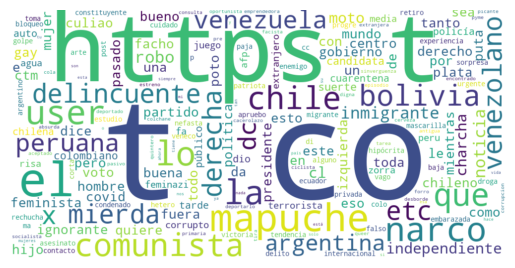

In [18]:
diccionario_train = mostrar_wordcloud(" ".join(vocabulario_train.get_itos()))


**notas**:
- se crea una instancia de la clase `WordCloud` con algunos parámetros de layout (ancho, alto, color de fondo...) y se invoca la función `generate()` que espera un texto en la entrada
- el texto que recibe la función es la base para calcular las frecuencias de cada palabra para dibujar la *nube de palabras*
- retorna `atributo words_` que corresponde al diccionario con las palabras y sus frecuencias (salida de la función `WordCloud`)
- la palabra más frecuente se toma como referencia y se normaliza a 1.0
  - las demás se expresan como fracción de esa frecuencia máxima.


#### 2.3. Cargar el `DataLoader`

se genera clase dataset por posible escalabilidad de los experimientos de más adelante, principalmente busca generar el objeto Pytorch para el DataLoader

In [19]:
# representa el dataset en formato PyTorch, entregando pares (secuencia_indices, etiqueta)
class TweetsDataset(Dataset):
    def __init__(self, df, vocabulario, tokenizador):
        self.textos = df["texto"].tolist()
        self.etiquetas = df["clase"].astype("category").cat.codes.tolist()
        self.vocabulario = vocabulario
        self.tokenizador = tokenizador

    def __len__(self):
        return len(self.textos)

    def __getitem__(self, idx):
        tokens = tokenizador.tokenize(self.textos[idx])
        indices = torch.tensor(self.vocabulario(tokens), dtype=torch.long)
        etiqueta = torch.tensor(self.etiquetas[idx], dtype=torch.long)
        return indices, etiqueta
    
# padding dinámico de cada lote para entregar tensores homogéneos al modelo.
def preparar_batch_secuencias(batch, vocabulario):
    secuencias, etiquetas = zip(*batch)
    longitudes = torch.tensor(
        [len(seq) for seq in secuencias], 
        dtype=torch.long
    )
    max_len = longitudes.max().item()
    matriz = torch.full(
        (len(secuencias), max_len), 
        vocabulario["<pad>"], 
        dtype=torch.long
    )
    for i, seq in enumerate(secuencias):
        matriz[i, : len(seq)] = seq

    return matriz, torch.stack(etiquetas), longitudes


**dataloader para partición de entrenamiento**:

In [20]:
train_dataset = TweetsDataset(
    train_df, 
    vocabulario_train,
    tokenizador
)

collate_fn_train = partial(preparar_batch_secuencias, vocabulario=vocabulario_train)

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate_fn_train,
    pin_memory=False,
    num_workers=0
)

print("[INFO] DataLoader train generado correctamente")


[INFO] DataLoader train generado correctamente


**dataloader para partición de validación**:

In [21]:
val_dataset = TweetsDataset(
    val_df, 
    vocabulario_train,
    tokenizador
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_fn_train,
    pin_memory=False,
    num_workers=0
)
print("[INFO] DataLoader validation generado correctamente")


[INFO] DataLoader validation generado correctamente


#### 2.4. Definir Rede Recurrentes

Para realizar el benchmark se han seleccionado tres variantes de clasificadores recurrentes. Cada arquitectura parte de embeddings entrenables y secuencias con padding enmascarado, pero varía en el tipo de bloque recurrente y en la forma de condensar la información temporal. La siguiente tabla resume sus componentes clave y el objetivo que persigue cada modificación.

| Clasificador | Arquitectura base | Aspectos diferenciadores |
|--------------|-------------------|---------------------------|
| **ClasificadorBiGRUBase** | Embeddings entrenables seguidos de una GRU bidireccional; se usan los estados finales (forward/backward) concatenados y una capa densa con dropout. | Diseño más simple: resume cada texto solo con el último estado oculto de la BiGRU, lo que funciona bien si la información relevante aparece al final de la secuencia. |
| **ClasificadorBiLSTM** | Misma tubería de embeddings y packing, pero con una LSTM bidireccional; concatena los últimos estados `h_n` y aplica dropout + proyección lineal. | Sustituye GRU por LSTM para manejar dependencias largas mediante compuertas `input/forget/output`; útil cuando las secuencias requieren una memoria más estable que la GRU pura. |
| **ClasificadorBiGRUConPooling** | BiGRU idéntica al primer modelo, pero en lugar de tomar el último estado usa las salidas completas, aplica máscara de padding y obtiene una representación mediante mean pooling antes de la capa densa. | Capta información distribuida en toda la secuencia, no solo en el final; el pooling enmascarado lo vuelve más robusto a longitudes variables y permite que tokens intermedios influyan en la decisión. |


##### 2.4.1 ClasificadorGRU

ClasificadorBiGRUBase:
- variante GRU “clásica” y bidireccional
- usa el último estado oculto de forward + backward

In [22]:
class ClasificadorBiGRUBase(nn.Module):
    def __init__(
        self, 
        vocabulario,
        vocab_size, 
        embedding_dim, 
        hidden_dim, 
        num_layers,
        dropout,
        num_clases
    ):
        super().__init__()
        print("[INFO] Inicializando ClasificadorBiGRUBase")
        print(f" hyperparámetros: vocab_size={vocab_size}, embedding_dim={embedding_dim}, "
              f"hidden_dim={hidden_dim}, num_layers={num_layers}, dropout={dropout}, "
              f"num_clases={num_clases}")
        
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=vocabulario["<pad>"]
        )
        
        # dropout interno de GRU solo si num_layers > 1, resuelve warning
        # warning: dropout option adds dropout after all but last recurrent layer, 
        # so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1

        rnn_dropout = dropout if num_layers > 1 else 0.0
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=rnn_dropout
        )
        # Dropout en la cabeza (se aplica siempre)
        self.dropout = nn.Dropout(dropout)
        self.proyector = nn.Linear(hidden_dim * 2, num_clases)

    def forward(self, secuencias, longitudes):
        emb = self.embedding(secuencias)  # (B, T, E)
        empaquetado = nn.utils.rnn.pack_padded_sequence(
            emb, longitudes.cpu(), batch_first=True, enforce_sorted=False
        )
        _, estado_final = self.gru(empaquetado)  # estado_final: (num_layers*2, B, H)
        # últimas dos filas: forward y backward de la última capa
        estado_concat = torch.cat((estado_final[-2], estado_final[-1]), dim=1)  # (B, 2H)
        logits = self.proyector(self.dropout(estado_concat))
        return logits
    

**notas**:
- *hiperparámetros principales*:
  - `EMBEDDING_DIM`: tamaño de los embeddings (nn.Embedding)
    - controla la dimensión del espacio vectorial donde se proyecta cada token
    - valores a evaluar 64, 128, 256 (evaluando capacidad/memoria)
  - `HIDDEN_DIM`: número de unidades ocultas en la GRU
    - define cuánta información puede retener cada dirección
    - subir este parámetro aumentaría la capacidad pero también el costo computacional
  - `NUM_LAYERS`: cantidad de capas de la red GRU 
    - más capas debiesen capturar patrones más complejos
  - `DROPOUT`: probabilidad de desactivar neuronas entre la GRU y la capa finalz
    - debiese ayudar a prevenir sobreajuste

##### 2.4.2 ClasificadorBiLSTM

- misma estructura que ClasificadorBiGRUBase pero con LSTM
- permitirá comparación GRU vs LSTM:
  - GRU -> más ligera, menos parámetros
  - LSTM -> mejor para dependencias largas

In [23]:
class ClasificadorBiLSTM(nn.Module):
    def __init__(
        self, 
        vocabulario,
        vocab_size, 
        embedding_dim, 
        hidden_dim, 
        num_layers,
        dropout,
        num_clases
    ):
        super().__init__()
        print("[INFO] Inicializando ClasificadorBiLSTM")
        print(f" hyperparámetros: vocab_size={vocab_size}, embedding_dim={embedding_dim}, "
              f"hidden_dim={hidden_dim}, num_layers={num_layers}, dropout={dropout}, "
              f"num_clases={num_clases}")
        
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=vocabulario["<pad>"]
        )
        
        rnn_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=rnn_dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.proyector = nn.Linear(hidden_dim * 2, num_clases)

    def forward(self, secuencias, longitudes):
        emb = self.embedding(secuencias)  # (B, T, E)
        empaquetado = nn.utils.rnn.pack_padded_sequence(
            emb, longitudes.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(empaquetado)  # h_n: (num_layers*2, B, H)
        estado_concat = torch.cat((h_n[-2], h_n[-1]), dim=1)  # (B, 2H)
        logits = self.proyector(self.dropout(estado_concat))
        return logits


##### 2.4.2 ClasificadorBiGRUConPooling

- usa toda la secuencia en vez del último estado
- incorpora mean pooling con máscara sobre (B, T, 2H)
- podría ser útil cuando los tweets tienen información repartida en toda la frase

In [24]:
class ClasificadorBiGRUConPooling(nn.Module):
    def __init__(
        self,
        vocabulario,
        vocab_size,
        embedding_dim,
        hidden_dim,
        num_layers,
        dropout,
        num_clases,
    ):
        super().__init__()
        print("[INFO] Inicializando ClasificadorBiGRUConPooling")
        print(f" hyperparámetros: vocab_size={vocab_size}, embedding_dim={embedding_dim}, "
              f"hidden_dim={hidden_dim}, num_layers={num_layers}, dropout={dropout}, "
              f"num_clases={num_clases}")
        
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=vocabulario["<pad>"]
        )
        
        rnn_dropout = dropout if num_layers > 1 else 0.0
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=rnn_dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.proyector = nn.Linear(hidden_dim * 2, num_clases)

    def forward(self, secuencias, longitudes):
        # secuencias: (B, T)
        emb = self.embedding(secuencias)  # (B, T, E)

        empaquetado = nn.utils.rnn.pack_padded_sequence(
            emb, longitudes.cpu(), batch_first=True, enforce_sorted=False
        )
        salida_empaquetada, _ = self.gru(empaquetado)
        salida, _ = nn.utils.rnn.pad_packed_sequence(
            salida_empaquetada, batch_first=True
        )  # salida: (B, T, 2H)

        # máscara para ignorar padding en el pooling
        device = longitudes.device
        B, T, _ = salida.shape
        rangos = torch.arange(T, device=device).unsqueeze(0)  # (1, T)
        mask = (rangos < longitudes.unsqueeze(1)).unsqueeze(-1)  # (B, T, 1)

        salida_masc = salida * mask  # paddings -> 0
        sum_hidden = salida_masc.sum(dim=1)  # (B, 2H)
        lengths = longitudes.unsqueeze(1)    # (B, 1)
        representacion = sum_hidden / lengths  # (B, 2H)

        logits = self.proyector(self.dropout(representacion))
        return logits


**función utilitaria para crear los modelos**:

In [25]:
def crear_modelo_rnn(config, vocabulario, num_clases, dispositivo):
    arquitectura = config["arquitectura"]
    
    if arquitectura == "bigru_base":
        modelo = ClasificadorBiGRUBase(
            vocabulario=vocabulario,
            vocab_size=len(vocabulario),
            embedding_dim=config["embedding_dim"],
            hidden_dim=config["hidden_dim"],
            num_layers=config["num_layers"],
            dropout=config["dropout"],
            num_clases=num_clases,
        )
    elif arquitectura == "bilstm":
        modelo = ClasificadorBiLSTM(
            vocabulario=vocabulario,
            vocab_size=len(vocabulario),
            embedding_dim=config["embedding_dim"],
            hidden_dim=config["hidden_dim"],
            num_layers=config["num_layers"],
            dropout=config["dropout"],
            num_clases=num_clases,
        )
    elif arquitectura == "bigru_pool":
        modelo = ClasificadorBiGRUConPooling(
            vocabulario=vocabulario,
            vocab_size=len(vocabulario),
            embedding_dim=config["embedding_dim"],
            hidden_dim=config["hidden_dim"],
            num_layers=config["num_layers"],
            dropout=config["dropout"],
            num_clases=num_clases,
        )
    else:
        raise ValueError(f"Arquitectura desconocida: {arquitectura}")
    
    return modelo.to(dispositivo)


#### 2.5. Funciones de Entrenamiento y Evaluación

**función de evaluación**:

In [26]:
def evaluar_en_validacion(modelo, funcion_perdida, val_loader, dispositivo):
    modelo.eval()
    perdida_acumulada = 0.0
    aciertos = 0
    total = 0

    with torch.no_grad():
        for lotes, etiquetas, longitudes in val_loader:
            lotes = lotes.to(dispositivo)
            etiquetas = etiquetas.to(dispositivo)
            longitudes = longitudes.to(dispositivo)

            logits = modelo(lotes, longitudes)
            perdida = funcion_perdida(logits, etiquetas)

            perdida_acumulada += perdida.item()
            pred = logits.argmax(dim=1)
            aciertos += (pred == etiquetas).sum().item()
            total += etiquetas.size(0)

    perdida_promedio = perdida_acumulada / len(val_loader)
    exactitud = aciertos / total

    return perdida_promedio, exactitud


**notas**:
 - se evalúa el modelo en el conjunto de validación sin afectar los pesos
 - pone al modelo en modo evaluación (model.eval())
 - recorre cada batch del val_loader desactivando el gradiente (torch.no_grad())
   - mueve tensores al dispositivo
   - obtiene logits
   - calcula la pérdida con la función que se pasa por parámetro
   - acumula tanto la suma de pérdidas como el número de aciertos (argmax contra etiquetas)
 - finalmente divide la pérdida acumulada entre la cantidad de batches para obtener la pérdida media y calcula la exactitud total (aciertos / total)
 - retorna par perdida_promedio y exactitud para reportar métricas de validación al cierre de cada época

**función para generar predicciones**:

In [27]:
def generar_predicciones(modelo, loader, dispositivo):
    modelo.eval()
    reales, logits_acumulados = [], []
    with torch.no_grad():
        for lotes, etiquetas, longitudes in loader:
            lotes = lotes.to(dispositivo)
            etiquetas = etiquetas.to(dispositivo)
            longitudes = longitudes.to(dispositivo)

            logits = modelo(lotes, longitudes)
            logits_acumulados.append(logits.cpu())
            reales.append(etiquetas.cpu())

    reales = torch.cat(reales).numpy()
    predichos = torch.cat(logits_acumulados).softmax(dim=-1).argmax(dim=-1).numpy()
    print(f"[INFO] Predicciones generadas: {len(predichos)} ejemplos procesados.")
    return reales, predichos


**notas**:
- corre el modelo en modo evaluación sobre un loader (train/val/test), 
- desactiva gradientes y acumula todos los logits/etiquetas reales
- al final concatena los tensores, aplica softmax para obtener probabilidades, toma el argmax para sacar la clase predicha de cada ejemplo y devuelve dos arrays NumPy: las etiquetas reales y las predicciones. También imprime cuántos ejemplos procesó

**funciones para recuperar checkpoints y no ejecutar entrenamientos completos repetidamente**:

In [ ]:
def generar_rutas_checkpoint(
    modelo,
    config,
    funcion_perdida,
    optimizador,
    epocas, 
):
    metadata = {
        "modelo": modelo.__class__.__name__,
        "config": config,
        "funcion_perdida": funcion_perdida.__class__.__name__,
        "optimizador": optimizador.__class__.__name__,
        "opt_params": getattr(optimizador, "defaults", {}),
        "epocas": epocas,
    }
    signature = hashlib.md5(
        json.dumps(metadata, sort_keys=True, default=str).encode("utf-8")
    ).hexdigest()
    base = f"{metadata['modelo']}_{config['nombre']}_{signature}"
    ckpt_path = DIR_CHECKP / f"{base}.pt"
    summary_path = DIR_CHECKP / f"{base}_summary.json"
    return ckpt_path, summary_path

def cargar_checkpoint(
        modelo,
        ckpt_path, 
        summary_path
):
    if ckpt_path.exists() and summary_path.exists():
        print("[INFO] Checkpoint compatible encontrado. Recuperando entrenamiento...")
        modelo.load_state_dict(torch.load(ckpt_path, map_location=dispositivo))
        with summary_path.open() as f:
            return json.load(f)
    return None


**función para entrenamiento de los modelos**:

In [ ]:
def entrenar_modelo(
    modelo,
    funcion_perdida,
    optimizador,
    train_loader,
    val_loader,
    epocas,
    dispositivo,
    config
):
    ruta_checkpoint, ruta_resumen = generar_rutas_checkpoint(
        modelo,
        config,
        funcion_perdida,
        optimizador,
        epocas
    )
    resumen_cache = cargar_checkpoint(
        modelo, 
        ruta_checkpoint, 
        ruta_resumen
    )
    if resumen_cache:
        print(f" - experimento: {config['nombre']}")
        print("[INFO] Entrenamiento reutilizado desde respaldo.")
        return resumen_cache

    print(f"[INFO] Iniciando entrenamiento del modelo {modelo.__class__.__name__}")
    print(f" - experimento: {config['nombre']}")
    print(f" - epocas: {epocas}")
    print(f" - dispositivo: {dispositivo}")
    print("-" * 100)

    mejor_val_loss = math.inf
    mejor_val_acc = 0.0
    mejor_epoca = 0

    historia = []  # guarda los datos de cada época para análisis posterior

    for epoca in range(1, epocas + 1):
        inicio_epoca = time.time()

        print()
        print(f"[Época {epoca:02d}], modelo: {modelo.__class__.__name__}")

        modelo.train()
        perdida_acumulada = 0.0
        aciertos = 0
        total = 0

        # imprimir 4 veces por época
        imprimir_cada = max(1, len(train_loader) // 6)

        btch_contador = 0
        for i, (lotes, etiquetas, longitudes) in enumerate(train_loader, start=1):
            lotes = lotes.to(dispositivo)
            etiquetas = etiquetas.to(dispositivo)
            longitudes = longitudes.to(dispositivo)

            optimizador.zero_grad()
            logits = modelo(lotes, longitudes)
            perdida = funcion_perdida(logits, etiquetas)
            perdida.backward()
            optimizador.step()

            pérdida_batch = perdida.item()
            perdida_acumulada += pérdida_batch

            pred = logits.argmax(dim=1)
            aciertos += (pred == etiquetas).sum().item()
            total += etiquetas.size(0)

            if i % imprimir_cada == 0:
                btch_contador += 1
                print(
                    f" - batch({btch_contador}): {i:03d}/{len(train_loader)}, "
                    f"loss_media: {perdida_acumulada / i:.4f}, "
                    f"acc_media: {aciertos / total:.4f}"
                )

        perdida_train = perdida_acumulada / len(train_loader)
        exactitud_train = aciertos / total

        print(
            f"[Época {epoca:02d}] pérdida_entrenamiento: {perdida_train:.4f}, "
            f"exactitud_entrenamiento: {exactitud_train:.4f}"
        )

        # validación
        perdida_val, exactitud_val = evaluar_en_validacion(
            modelo, 
            funcion_perdida, 
            val_loader, 
            dispositivo
        )

        duracion = time.time() - inicio_epoca

        # actualización de best val_loss
        if perdida_val < mejor_val_loss:
            mejor_val_loss = perdida_val
            mejor_val_acc = exactitud_val
            mejor_epoca = epoca
            torch.save(modelo.state_dict(), ruta_checkpoint)

        print(
            f"[Época {epoca:02d}] pérdida_validación: {perdida_val:.4f}, "
            f"exactitud_validación: {exactitud_val:.4f}, "
            f"tiempo: {duracion:.1f}s"
        )

        historia.append({
            "epoca": epoca,
            "train_loss": perdida_train,
            "train_acc": exactitud_train,
            "val_loss": perdida_val,
            "val_acc": exactitud_val,
            "tiempo_s": duracion,
        })

    # resultado final del entrenamiento
    resumen = {
        "mejor_epoca": mejor_epoca,
        "mejor_val_loss": mejor_val_loss,
        "mejor_val_acc": mejor_val_acc,
        "historia": historia,
    }
    with ruta_resumen.open("w") as f:
        json.dump(resumen, f, indent=2)

    return resumen


**notas**:
- entrena cualquier clasificador recurrente y devuelve un resumen con la mejor época y el historial completo de métricas
  - imprime metadata inicial y, por época, muestra el progreso de entrenamiento (pérdida y exactitud acumuladas)
  - calcula pérdida/accuracy promedio tras recorrer todo train_loader, luego llama a evaluar_en_validacion para obtener las métricas del set de validación y mide la duración de la época
  - actualiza un registro del “mejor modelo” según val_loss (también guarda la val_acc en esa época) y añade un diccionario a historia con train_loss, train_acc, val_loss, val_acc y tiempo_s
  - retorna un diccionario con mejor_epoca, mejor_val_loss, mejor_val_acc y la lista historia, que puedes convertir en DataFrame o usar para plots

#### 2.6. Definición de Experimentos

- EPOCAS_RNN = 7 fija cuántas épocas se entrenará cada modelo
- arquitecturas describe las tres variantes (bigru_base, bilstm, bigru_pool) con un tag para usar en el nombre del experimento
- configs_base contiene las combinaciones principales de hiperparámetros (dimensión de embeddings/hidden, dropout, LR, weight_decay)
- configs_extra agrega una última configuración con num_layers = 2 para ver el efecto de apilar capas
- el doble bucle construye experimentos: para cada arquitectura recorre configs_base y luego configs_extra, generando un diccionario con el nombre (exp_<tag>_<suffix>), la arquitectura y sus hiperparámetros. 

In [29]:
EPOCAS_RNN = 5

arquitecturas = [
    {"arquitectura": "bigru_base", "tag": "bigru"},
    {"arquitectura": "bilstm",     "tag": "bilstm"},
    {"arquitectura": "bigru_pool", "tag": "bigru_pool"},
]

configs_base = [
    {
        "suffix": "dim128_drop0.3",
        "embedding_dim": 128,
        "hidden_dim": 128,
        "num_layers": 1,
        "dropout": 0.3,
        "lr": 5e-4,
        "weight_decay": 1e-4,
    },
    {
        "suffix": "dim128_drop0.5",
        "embedding_dim": 128,
        "hidden_dim": 128,
        "num_layers": 1,
        "dropout": 0.5,
        "lr": 5e-4,
        "weight_decay": 1e-4,
    },
    {
        "suffix": "dim256_drop0.3",
        "embedding_dim": 256,
        "hidden_dim": 256,
        "num_layers": 1,
        "dropout": 0.3,
        "lr": 3e-4,      # lr más bajo para modelo más grande
        "weight_decay": 1e-4,
    },
]

# configs con 2 capas por arquitectura
configs_extra = [
    {
        "suffix": "2layers_dim128_drop0.3",
        "embedding_dim": 128,
        "hidden_dim": 128,
        "num_layers": 2,
        "dropout": 0.3,
        "lr": 5e-4,
        "weight_decay": 1e-4,
    },
]

experimentos = []

for arch in arquitecturas:
    for cfg in configs_base:
        exp = {
            "nombre": f"exp_{arch['tag']}_{cfg['suffix']}",
            "arquitectura": arch["arquitectura"],
            "embedding_dim": cfg["embedding_dim"],
            "hidden_dim": cfg["hidden_dim"],
            "num_layers": cfg["num_layers"],
            "dropout": cfg["dropout"],
            "lr": cfg["lr"],
            "weight_decay": cfg["weight_decay"],
            "epocas": EPOCAS_RNN,
        }
        experimentos.append(exp)

    # añadir también la config extra de 2 capas
    for cfg in configs_extra:
        exp = {
            "nombre": f"exp_{arch['tag']}_{cfg['suffix']}",
            "arquitectura": arch["arquitectura"],
            "embedding_dim": cfg["embedding_dim"],
            "hidden_dim": cfg["hidden_dim"],
            "num_layers": cfg["num_layers"],
            "dropout": cfg["dropout"],
            "lr": cfg["lr"],
            "weight_decay": cfg["weight_decay"],
            "epocas": EPOCAS_RNN,
        }
        experimentos.append(exp)

len(experimentos), experimentos[:3]


(12,
 [{'nombre': 'exp_bigru_dim128_drop0.3',
   'arquitectura': 'bigru_base',
   'embedding_dim': 128,
   'hidden_dim': 128,
   'num_layers': 1,
   'dropout': 0.3,
   'lr': 0.0005,
   'weight_decay': 0.0001,
   'epocas': 5},
  {'nombre': 'exp_bigru_dim128_drop0.5',
   'arquitectura': 'bigru_base',
   'embedding_dim': 128,
   'hidden_dim': 128,
   'num_layers': 1,
   'dropout': 0.5,
   'lr': 0.0005,
   'weight_decay': 0.0001,
   'epocas': 5},
  {'nombre': 'exp_bigru_dim256_drop0.3',
   'arquitectura': 'bigru_base',
   'embedding_dim': 256,
   'hidden_dim': 256,
   'num_layers': 1,
   'dropout': 0.3,
   'lr': 0.0003,
   'weight_decay': 0.0001,
   'epocas': 5}])

**notas**
- 3 arquitecturas × (3 configs base + 1 config extra) = 12 experimentos distintos

#### 2.7.  Ejecución de Experimentos

- itera por todas las configuraciones generadas en experimentos y, para cada una:
  - imprime encabezados para identificar el experimento (exp_<tag>_<suffix>)
  - construye el modelo mediante crear_modelo_rnn usando la arquitectura y los hiperparámetros de config
  - define función de pérdida CrossEntropyLoss y optimizador Adam con el lr y weight_decay especificados

In [ ]:
#borrar
for config in experimentos:
    print()
    print("=" * 100)
    print(f"[INFO] Iniciando experimento: {config['nombre']}")
    print("=" * 100)

    funcion_perdida = nn.CrossEntropyLoss()
    optimizador = torch.optim.Adam(
        modelo.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )

    modelo = crear_modelo_rnn(
        config=config,
        vocabulario=vocabulario_train,
        num_clases=len(target_classes),
        dispositivo=dispositivo,
    )

    ruta_checkpoint, ruta_resumen = generar_rutas_checkpoint(
        modelo,
        config,config,
        funcion_perdida,
        optimizador,
        epocas=config["epocas"]
    )

    print(f"[INFO] Ruta checkpoint: {ruta_checkpoint}")
    print(f"[INFO] Ruta resumen: {ruta_resumen}")


In [30]:
resultados = []
historiales = []

for config in experimentos:
    print()
    print("=" * 100)
    print(f"[INFO] Iniciando experimento: {config['nombre']}")
    print("=" * 100)

    torch.manual_seed(SEED) 

    modelo = crear_modelo_rnn(
        config=config,
        vocabulario=vocabulario_train,
        num_clases=len(target_classes),
        dispositivo=dispositivo,
    )

    funcion_perdida = nn.CrossEntropyLoss()
    optimizador = torch.optim.Adam(
        modelo.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )

    resumen = entrenar_modelo(
        modelo,
        funcion_perdida,
        optimizador,
        train_loader,
        val_loader,
        epocas=config["epocas"],
        dispositivo=dispositivo,
        config=config
    )

    resultados.append({
        "experimento": config["nombre"],
        "arquitectura": config["arquitectura"],
        "embedding_dim": config["embedding_dim"],
        "hidden_dim": config["hidden_dim"],
        "num_layers": config["num_layers"],
        "dropout": config["dropout"],
        "lr": config["lr"],
        "weight_decay": config["weight_decay"],
        "mejor_epoca": resumen["mejor_epoca"],
        "mejor_val_loss": resumen["mejor_val_loss"],
        "mejor_val_acc": resumen["mejor_val_acc"],
    })

    historial = pd.DataFrame(resumen["historia"])
    historial["experimento"] = config["nombre"]
    historiales.append(historial)
    historial.to_csv(f"{DIR_HIST}/{config['nombre']}_historial.csv", index=False)

df_historial_total = pd.concat(historiales, ignore_index=True)



[INFO] Iniciando experimento: exp_bigru_dim128_drop0.3
[INFO] Inicializando ClasificadorBiGRUBase
 hyperparámetros: vocab_size=28113, embedding_dim=128, hidden_dim=128, num_layers=1, dropout=0.3, num_clases=3
[INFO] Iniciando entrenamiento del modelo ClasificadorBiGRUBase
 - experimento: exp_bigru_dim128_drop0.3
 - epocas: 5
 - dispositivo: mps
----------------------------------------------------------------------------------------------------

[Época 01], modelo: ClasificadorBiGRUBase
 - batch(1): 025/153, loss_media: 1.0825, acc_media: 0.3919
 - batch(2): 050/153, loss_media: 1.0562, acc_media: 0.4297
 - batch(3): 075/153, loss_media: 1.0381, acc_media: 0.4523
 - batch(4): 100/153, loss_media: 1.0286, acc_media: 0.4636
 - batch(5): 125/153, loss_media: 1.0166, acc_media: 0.4746
 - batch(6): 150/153, loss_media: 1.0062, acc_media: 0.4860
[Época 01] pérdida_entrenamiento: 1.0053, exactitud_entrenamiento: 0.4874
[Época 01] pérdida_validación: 1.0142, exactitud_validación: 0.5088, tiemp

**dataframe con detalles de los experimentos**:

In [31]:
df_resultados_rnn = pd.DataFrame(resultados)
df_resultados_rnn = df_resultados_rnn.sort_values(by="mejor_val_acc", ascending=False)
print("[INFO] dataframe detalle entrenamiento de experimentos:")
print(f" - df_resultados_rnn.columns: {df_resultados_rnn.columns}")


[INFO] dataframe detalle entrenamiento de experimentos:
 - df_resultados_rnn.columns: Index(['experimento', 'arquitectura', 'embedding_dim', 'hidden_dim',
       'num_layers', 'dropout', 'lr', 'weight_decay', 'mejor_epoca',
       'mejor_val_loss', 'mejor_val_acc'],
      dtype='object')


#### 2.8. Evaluación de Modelos

**comparación de modelos**:

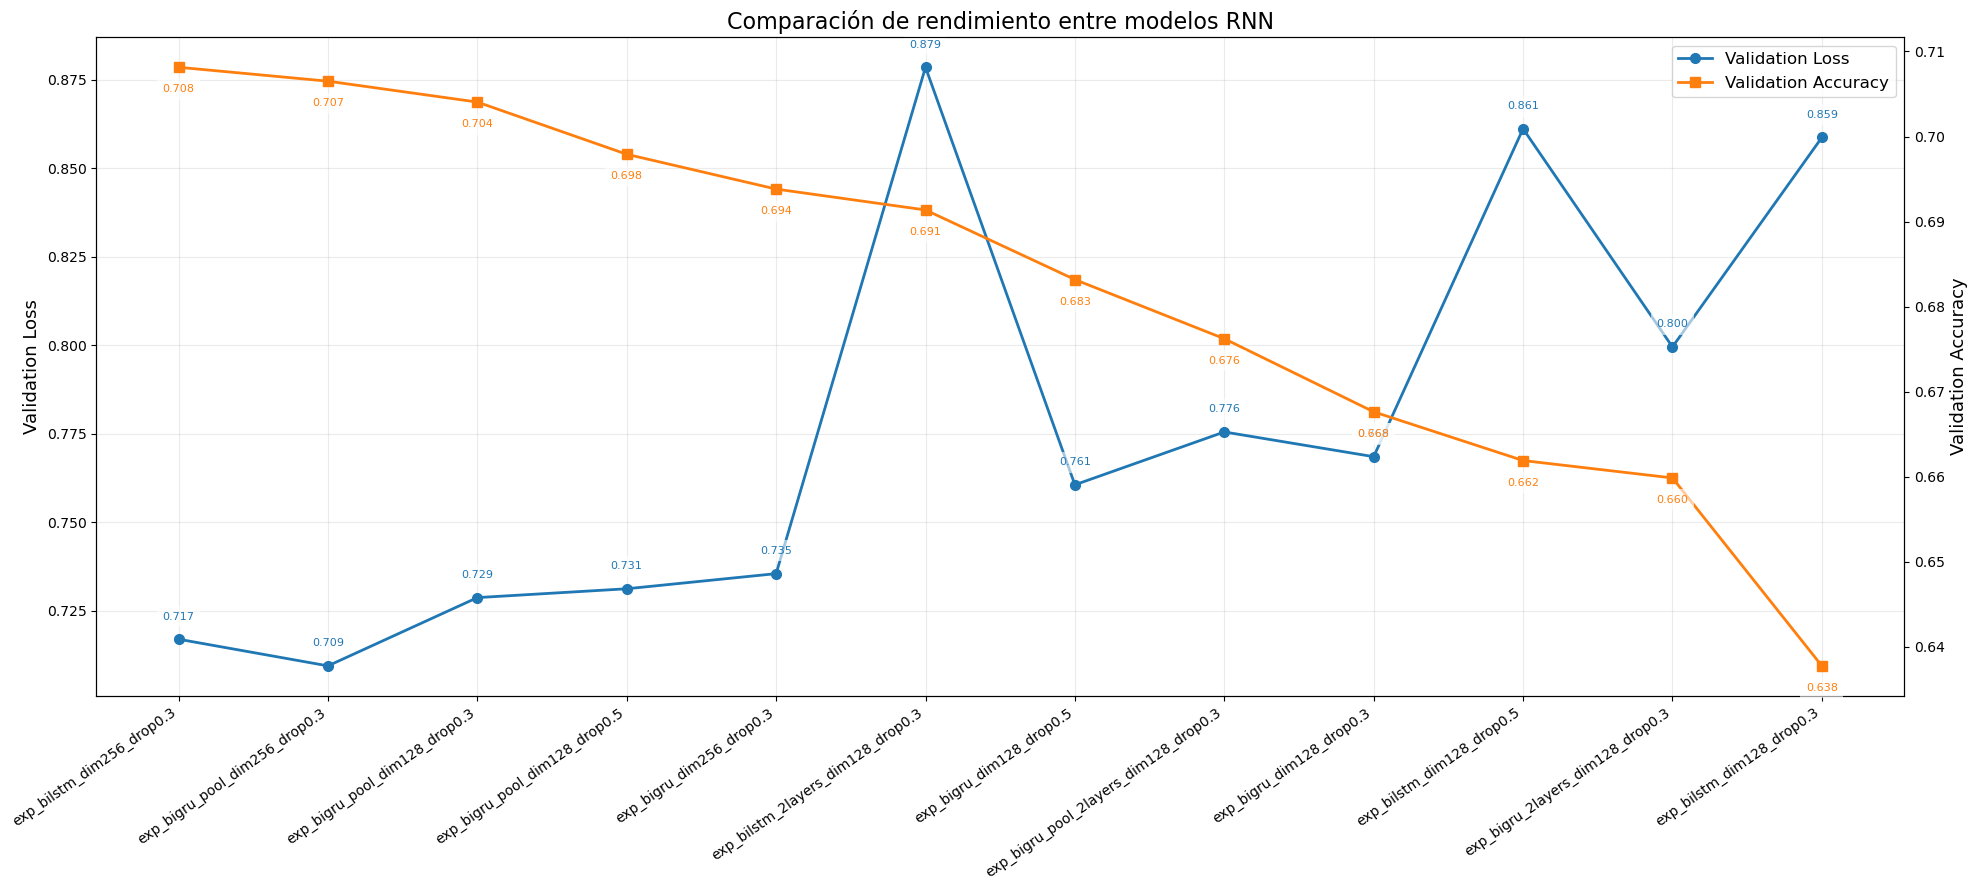

In [32]:
df_plot = df_resultados_rnn.copy()

fig, ax1 = plt.subplots(figsize=(20,9))
ax2 = ax1.twinx()

# paleta de colores
color_loss = "#1f77b4"
color_acc = "#ff7f0e"

# curva val_loss
ax1.plot(
    df_plot["experimento"],
    df_plot["mejor_val_loss"],
    marker="o",
    linewidth=2,
    markersize=7,
    color=color_loss,
    label="Validation Loss",
)

# curva val_acc
ax2.plot(
    df_plot["experimento"],
    df_plot["mejor_val_acc"],
    marker="s",
    linewidth=2,
    markersize=7,
    color=color_acc,
    label="Validation Accuracy",
)

# títulos y ejes
ax1.set_title("Comparación de rendimiento entre modelos RNN", fontsize=16)
ax1.set_ylabel("Validation Loss", fontsize=13)
ax2.set_ylabel("Validation Accuracy", fontsize=13)

# rotación y alineación de etiquetas en eje x
pos = range(len(df_plot))
ax1.set_xticks(pos)
ax1.set_xticklabels(df_plot["experimento"], rotation=35, ha="right")

ax2.set_xticks(pos)
ax2.set_xticklabels(df_plot["experimento"], rotation=35, ha="right")

# grid
ax1.grid(alpha=0.25)

# etiquetas numéricas en cada punto
for x, y in zip(df_plot["experimento"], df_plot["mejor_val_loss"]):
    ax1.text(
        x, y + 0.005, f"{y:.3f}",
        color=color_loss,
        fontsize=8,
        ha="center",
        va="bottom",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

for x, y in zip(df_plot["experimento"], df_plot["mejor_val_acc"]):
    ax2.text(
        x, y - 0.002, f"{y:.3f}",
        color=color_acc,
        fontsize=8,
        ha="center",
        va="top",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

# leyenda
lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right", fontsize=12)

plt.tight_layout()
plt.show()


In [33]:
df_resultados_rnn.to_csv("outputs/resultados_experimentos_rnn.csv", index=False)


**notas**:
- eel gráfico muestra que, conforme se incrementa la complejidad de las variantes RNN evaluadas, la pérdida de validación exhibe una tendencia ascendente con picos pronunciados (particularmente en exp_bilstm_dim256_drop0.3 y exp_bilstm_dim128_drop0.3), lo que sugiere sobreajuste o inestabilidad en esos diseños
- en paralelo, la exactitud de validación desciende de forma casi monotónica, pasando de 0.708 a 0.638, evidencia de un deterioro progresivo en la capacidad de generalización
- en conjunto, no se observa un modelo que supere consistentemente al resto
  - los experimentos con configuraciones más simples (por ejemplo exp_bilstm_dim256_drop0.3 y exp_bigru_pool_dim128_drop0.3) mantienen pérdidas moderadas y exactitudes superiores, por lo que conviene centrar los ajustes finos en esa región del espacio de hiperparámetros

**notas finales**:
- se exploraron múltiples variantes recurrentes (GRU, BiGRU, BiLSTM y combinaciones con pooling o capas adicionales) observando cómo el balance entre capacidad del modelo y regularización impacta directamente en la pérdida y la exactitud de validación
- si bien ninguna configuración logró una mejora significativa sostenida, los experimentos iniciales con arquitecturas moderadas y dropout controlado ofrecieron el mejor compromiso entre estabilidad y generalización, mientras que los modelos más profundos tendieron al sobreajuste
- esto sugiere concentrar los siguientes ajustes en refinar esas arquitecturas intermedias e introducir técnicas como ajuste fino de tasas de aprendizaje o early stopping para consolidar el rendimiento


#### 3.1. Importar y cargar BETO

**cargar BETO (tokenizador + modelo)**:

In [41]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

MODEL_NAME = "dccuchile/bert-base-spanish-wwm-uncased"

print(f"[INFO] Cargando modelo y tokenizador BERT: {MODEL_NAME}, disositivo: {dispositivo}")

beto_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

try:
    beto_model = AutoModelForMaskedLM.from_pretrained(
        MODEL_NAME,
        output_hidden_states=True,
        use_safetensors=True
    )
    print("[INFO] Modelo BERT cargado exitosamente con safetensors")

except ValueError as e:
    print(f"[Error] cargando modelo BERT with safetensors: {e}")
    beto_model = AutoModelForMaskedLM.from_pretrained(
        MODEL_NAME,
        output_hidden_states=True
    )
    print("[INFO] Modelo BERT cargado sin safetensors")


[INFO] Cargando modelo y tokenizador BERT: dccuchile/bert-base-spanish-wwm-uncased, disositivo: mps
[INFO] Modelo BERT cargado exitosamente con safetensors


**notas**
- utoModelForMaskedLM, estás cargando 
  - carga el modelo de pre-entrenamiento de tipo Masked Language Modeling (MLM)
  - es un modelo BERT que además de la parte backbone (“encoder”) tiene una cabeza de predicción de tokens enmascarados
- se tokeniza el texto con padding=True, truncation=True, max_length=…, return_tensors="pt"
- significa que el modelo contiene la capa principal (“BertModel”) + una capa adicional que toma el hidden state final y lo mapea hacia una distribución sobre el vocabulario del modelo (predicción del token enmascarado)

In [42]:
beto_model.to(dispositivo)
beto_model.eval() 


BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31002, 768, padding_idx=1)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwi

**validación de implementación**:

In [43]:
# prueba con un solo texto
texto_demo = ["Este es un texto de prueba para BETO."]
encoded_demo = beto_tokenizer(
    texto_demo,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)
encoded_demo = {k: v.to(dispositivo) for k, v in encoded_demo.items()}

with torch.no_grad():
    outputs_demo = beto_model(**encoded_demo)
    hidden_states_demo = outputs_demo.hidden_states
    last_hidden_demo = hidden_states_demo[-1]           # (batch_size=1, seq_len, hidden_dim)
    cls_demo = last_hidden_demo[:, 0, :]                 # (1, hidden_dim)
    print("Shape CLS embedding:", cls_demo.shape)


Shape CLS embedding: torch.Size([1, 768])


#### 3.2. Extracción de Embeddings 

extracción de embeddings con Transformers (using AutoModel) y AutoTokenizer

In [44]:
def obtener_embeddings_beto_en_lotes(
        texts, 
        batch_size=32, 
        max_length=128, 
        dispositivo=dispositivo
    ):
    all_embeddings = []
    for start in range(0, len(texts), batch_size):
        end = start + batch_size
        batch_texts = texts[start:end]

        # tokenizar
        encoded = beto_tokenizer(
            list(batch_texts),
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        # mover tensores al mismo dispositivo que el modelo
        encoded = {k: v.to(dispositivo) for k, v in encoded.items()}

        # extracción de features sin calcular gradientes
        with torch.no_grad():
            outputs = beto_model(**encoded)
            hidden_states = outputs.hidden_states        # tupla: (num_layers+1, batch, seq_len, hidden_dim)
            last_hidden = hidden_states[-1]               # (batch, seq_len, hidden_dim)
            cls_embeddings = last_hidden[:, 0, :]         # (batch, hidden_dim)

        # mover a CPU + numpy  
        cls_numpy = cls_embeddings.cpu().numpy()
        all_embeddings.append(cls_numpy)

    features = np.vstack(all_embeddings)
    return features


**notas**:
- la función obtener_embeddings_beto_en_lotes toma una lista de textos y los procesa por lotes para generar representaciones vectoriales con BETO 
- para cada bloque de tamaño batch_size, tokeniza los textos con padding y truncado hasta max_length, mueve los tensores al dispositivo del modelo, ejecuta BETO sin calcular gradientes y extrae el embedding del token [CLS] de la última capa oculta, que resume la secuencia completa
- esos embeddings se copian a CPU, se acumulan y finalmente se apilan en una matriz numpy donde cada fila corresponde a un texto de entrada

In [45]:
X_beto_train = train_df["texto"].tolist()
y_beto_train = train_df["clase"].astype("category").cat.codes.to_numpy()

X_beto_val = val_df["texto"].tolist()
y_beto_val = val_df["clase"].astype("category").cat.codes.to_numpy()


In [46]:
# si MPS se queda sin memoria, baja el batch_size a 8 o 16
print("[INFO] Extrayendo embeddings de BETO para TRAIN...")
X_beto_train_emb = obtener_embeddings_beto_en_lotes(
    X_beto_train, 
    batch_size=32, 
    max_length=128, 
    dispositivo=dispositivo
)
print("X_beto_train_emb:", X_beto_train_emb.shape)


[INFO] Extrayendo embeddings de BETO para TRAIN...
X_beto_train_emb: (9771, 768)


**notas**:
- se ejecuta obtener_embeddings_beto_en_lotes sobre todo el conjunto de entrenamiento (X_beto_train) con lotes de 32 y secuencias truncadas a 128 tokens usando el dispositivo indicado (por ejemplo, GPU MPS)
- se observa salida X_beto_train_emb: (9771, 768) que confirma que se generó una matriz con 9.771 ejemplos y vectores de 768 dimensiones (la salida estándar de BETO)

In [47]:
print("[INFO] Extrayendo embeddings de BETO para VAL...")
X_beto_val_emb = obtener_embeddings_beto_en_lotes(
    X_beto_val,
    batch_size=32, 
    max_length=128, 
    dispositivo=dispositivo
)
print("X_beto_val_emb:", X_beto_val_emb.shape)


[INFO] Extrayendo embeddings de BETO para VAL...
X_beto_val_emb: (2443, 768)


**notas**
- se observan resultados homólogos entre particiones de entrenamiento y validación

In [ ]:
np.save("outputs/X_beto_train_emb.npy", X_beto_train_emb)
np.save("outputs/X_beto_val_emb.npy", X_beto_val_emb)
np.save("outputs/y_beto_train.npy", y_beto_train)
np.save("outputs/y_beto_val.npy", y_beto_val)


**notas**:
 - guarda en disco los arreglos NumPy con los embeddings y etiquetas obtenidos de BETO

**respaldo en parquets**:

In [49]:
df_train = pd.DataFrame(X_beto_train_emb)
df_val = pd.DataFrame(X_beto_val_emb)

df_train.to_parquet(f"{DIR_PARQUETS}/X_beto_train_emb.parquet", index=False)
df_val.to_parquet(f"{DIR_PARQUETS}/X_beto_val_emb.parquet", index=False)


#### 3.3. Función de Entrenamiento

In [50]:
# entrena un clasificador sobre los embeddings de BETO y muestra métricas en validación
def entrenar_y_evaluar_clasificador(nombre, clf, X_train, y_train, X_val, y_val):
    
    print(f"\n{'='*80}")
    print(f"[INFO] Entrenando clasificador: {nombre}")
    
    # Entrenar
    clf.fit(X_train, y_train)

    # Predecir
    y_val_pred = clf.predict(X_val)

    # Métricas
    acc = accuracy_score(y_val, y_val_pred)
    reporte = classification_report(y_val, y_val_pred, digits=4)
    reporte_dict = classification_report(y_val, y_val_pred, digits=4, output_dict=True)

    print(f"[RESULTADO] Accuracy VALIDACIÓN ({nombre}): {acc:.4f}\n")
    print(f"[RESULTADO] Reporte de clasificación ({nombre}):")
    print(reporte)

    return clf, y_val_pred, acc, reporte_dict


**notas**:
- entrena el modelo (fit), predice sobre el conjunto de validación (predict), calcula la exactitud y el informe de clasificación (classification_report y su versión en diccionario), imprime todo, y devuelve el clasificador entrenado, las predicciones, la accuracy y el desglose de métricas para análisis posterior

#### 3.4. Clasificadores

##### 3.4.1. Clasificador 1 - Regresión Logística

**definición**:

In [ ]:
modelo_beto_logreg = LogisticRegression(
    max_iter=2000, 
    n_jobs=-1
)
print("[INFO] Hiperparámetros del clasificador BETO + LogisticRegression:")
pprint(modelo_beto_logreg.get_params(), width=80)

if hasattr(modelo_beto_logreg, "coef_"):
    print("\nForma de la matriz de coeficientes:", modelo_beto_logreg.coef_.shape)
    print("Forma del vector de biases:", modelo_beto_logreg.intercept_.shape)
else:
    print("\n[AVISO] Aún no se ha entrenado el modelo; ejecuta primero la celda de entrenamiento.")


**notas**:
- la arquitectura final combina una etapa de representación y otra de clasificación: 
  - primero, cada texto se transforma en un embedding de 768 dimensiones al extraer el vector [CLS] de la última capa de BETO (modelo BERT entrenado en español)
  - esos embeddings alimentan un clasificador lineal, en este caso una regresión logística multinomial equipada con regularización y entrenamiento máximo con 2000 iteraciones y paralelización total (n_jobs=-1)
  - la red profunda (BETO) actúa como extractor de características, mientras que la capa logística se encarga de aprender los hiperplanos de decisión para distinguir las clases normal, incivilidad y odio
  - hiperparámetros de la regresión logística
    - regularización L2, solver lbfgs, 2000 iteraciones, ejecución paralela, etc. 
    - confirma que tras el entrenamiento se obtuvieron coeficientes de tamaño (3, 768) y biases (3,), lo que corresponde a un modelo multinomial con tres clases y 768 características provenientes de los embeddings BETO

**entrenamiento**:

In [52]:
modelo_beto_logreg, y_pred_beto_logreg, acc_beto_logreg, rep_beto_logreg = entrenar_y_evaluar_clasificador(
    "BETO + LogisticRegression",
    modelo_beto_logreg,
    X_beto_train_emb, 
    y_beto_train,
    X_beto_val_emb, 
    y_beto_val
)



[INFO] Entrenando clasificador: BETO + LogisticRegression


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

[RESULTADO] Accuracy VALIDACIÓN (BETO + LogisticRegression): 0.6742

[RESULTADO] Reporte de clasificación (BETO + LogisticRegression):
              precision    recall  f1-score   support

           0     0.7074    0.7419    0.7242      1085
           1     0.6580    0.6764    0.6671       856
           2     0.6188    0.5239    0.5674       502

    accuracy                         0.6742      2443
   macro avg     0.6614    0.6474    0.6529      2443
weighted avg     0.6719    0.6742    0.6720      2443



**notas**:
- una vez entrenado el clasificador BETO + LogisticRegression, la exactitud de validación alcanza 0.6742 y se obtienen las métricas detalladas:
  - mejor rendimiento en la clase 0 (precisión 0.707, recall 0.742)
  - desempeño intermedio en la clase 1 y más bajo en la clase 2
  - mantiene un F1 razonable (0.567)

**matriz de confusión**

In [53]:
modelo_beto_logreg_cm = confusion_matrix(y_beto_val, y_pred_beto_logreg)
print("[INFO] Matriz de confusión:")
ConfusionMatrixDisplay(modelo_beto_logreg_cm, display_labels=target_classes).plot(cmap="Blues")
plt.title("Matriz de confusión - BETO + LogisticRegression")
plt.show()


[INFO] Matriz de confusión:
[[805 199  81]
 [196 579  81]
 [137 102 263]]


**notas**:
- la matriz confirma que el modelo acierta mayoritariamente en la clase normal (805 aciertos, pocos falsos positivos)
- mantiene un rendimiento razonable en incivilidad (579 aciertos contra 196 y 81 errores)
- la clase odio sigue siendo la más problemática: 
  - solo 263 aciertos frente a 239 confusiones repartidas en las otras dos clases, lo que coincide con el recall más bajo visto en el reporte de métricas

##### 3.4.2. Clasificador 1 - SVM Lineal

**definición**:

In [ ]:
from sklearn.svm import LinearSVC
clf_beto_svm = LinearSVC(max_iter=5000)

print("[INFO] Hiperparámetros del clasificador BETO + LinearSVC:")
pprint(clf_beto_svm.get_params(), width=80)

if hasattr(clf_beto_svm, "coef_"):
    print("\nForma de la matriz de coeficientes:", clf_beto_svm.coef_.shape)
    print("Forma del vector de biases:", clf_beto_svm.intercept_.shape)
else:
    print("\n[AVISO] Aún no se ha entrenado el modelo; ejecuta primero la celda de entrenamiento.")


**notas**:
- hiperparámetros por defecto del LinearSVC (regularización L2, pérdida “squared hinge”, esquema “one-vs-rest”, 5 000 iteraciones)
- la matriz de coeficientes y el vector de bias también confirman la dimensionalidad esperada: 
  - tres clasificaciones binarias (una por clase) sobre 768 características

**entrenamiento**

In [55]:
modelo_beto_svm, y_pred_beto_svm, acc_beto_svm, rep_beto_svm = entrenar_y_evaluar_clasificador(
    "BETO + LinearSVC",
    clf_beto_svm,
    X_beto_train_emb, 
    y_beto_train,
    X_beto_val_emb, 
    y_beto_val
)



[INFO] Entrenando clasificador: BETO + LinearSVC
[RESULTADO] Accuracy VALIDACIÓN (BETO + LinearSVC): 0.6742

[RESULTADO] Reporte de clasificación (BETO + LinearSVC):
              precision    recall  f1-score   support

           0     0.7011    0.7567    0.7278      1085
           1     0.6514    0.6834    0.6670       856
           2     0.6444    0.4801    0.5502       502

    accuracy                         0.6742      2443
   macro avg     0.6656    0.6401    0.6484      2443
weighted avg     0.6721    0.6742    0.6700      2443



**matriz de confusión**:

In [ ]:
modelo_beto_svm_cm = confusion_matrix(y_beto_val, y_pred_beto_svm)
print("[INFO] Matriz de confusión:")
ConfusionMatrixDisplay(modelo_beto_svm_cm, display_labels=target_classes).plot(cmap="Greens")
plt.title("Matriz de confusión - BETO + LinearSVC")
plt.show()


[INFO] Matriz de confusión:
[[821 199  65]
 [203 585  68]
 [147 114 241]]


**notas**:
- la matriz de confusión del modelo BETO + LinearSVC refleja un patrón parecido al de la regresión logística, pero con ligeras mejoras: 
  - la clase normal presenta aún más aciertos (821)
  - incivilidad también sube a 585
  - odio aumenta el número de predicciones correctas a 241 (aunque sigue siendo la clase con más confusiones, sobre todo hacia normal)
- esto sugiere que el SVM lineal ofrece un ajuste un poco más equilibrado en comparación con el clasificador logístico, especialmente en la clase minoritaria


#### 3.4. Reporte de evaluación

In [57]:
# predicciones en el set de TEST usando los embeddings BETO
y_pred_beto_svm = modelo_beto_svm.predict(X_beto_val_emb)
y_pred_beto_logreg = modelo_beto_logreg.predict(X_beto_val_emb)
df_predicciones_beto = val_df[["texto", "clase"]].copy()
df_predicciones_beto["pred_svm"] = y_pred_beto_svm
df_predicciones_beto["pred_logreg"] = y_pred_beto_logreg


**notas**:
 - predicciones del conjunto de validación con los dos clasificadores entrenados sobre embeddings BETO (SVM y regresión logística) 
 - aplican predict usando X_beto_val_emb, luego copian del val_df las columnas originales texto y clase

In [58]:
for nombre, y_pred in [
    ("BETO + LinearSVC", y_pred_beto_svm),
    ("BETO + LogisticRegression", y_pred_beto_logreg),
]:
    print(f"\n=== {nombre} ===")
    print(classification_report(y_beto_val, y_pred, digits=4))
    ...



=== BETO + LinearSVC ===
              precision    recall  f1-score   support

           0     0.7011    0.7567    0.7278      1085
           1     0.6514    0.6834    0.6670       856
           2     0.6444    0.4801    0.5502       502

    accuracy                         0.6742      2443
   macro avg     0.6656    0.6401    0.6484      2443
weighted avg     0.6721    0.6742    0.6700      2443


=== BETO + LogisticRegression ===
              precision    recall  f1-score   support

           0     0.7074    0.7419    0.7242      1085
           1     0.6580    0.6764    0.6671       856
           2     0.6188    0.5239    0.5674       502

    accuracy                         0.6742      2443
   macro avg     0.6614    0.6474    0.6529      2443
weighted avg     0.6719    0.6742    0.6720      2443



**notas**:
- BETO + LinearSVC y BETO + LogisticRegression alcanzan la misma exactitud global (0.6742), pero sus perfiles por clase difieren ligeramente:
- BETO + SVM ofrece recall más alto en la clase “normal” y precisión más equilibrada en “odio”, mientras que la regresión logística mantiene mejor recall en la clase minoritaria (0.5239 vs 0.4801) a costa de algo de precisión

**métricas por clase (BETO + LogisticRegression vs LinearSVC)**:

In [ ]:
resultados = []

for nombre, y_pred in [
    ("BETO + LogisticRegression", y_pred_beto_logreg),
    ("BETO + LinearSVC", y_pred_beto_svm),
]:
    reporte = classification_report(
        y_beto_val,
        y_pred,
        target_names=target_classes,
        digits=4,
        output_dict=True,
    )
    df = (
        pd.DataFrame(reporte)
        .loc[["precision", "recall", "f1-score"], target_classes]
        .T.reset_index()
        .rename(columns={"index": "clase"})
    )
    df["modelo"] = nombre
    resultados.append(df)

metricas_df = pd.concat(resultados, ignore_index=True)

metricas = ["precision", "recall", "f1-score"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, metric in zip(axes, metricas):
    logistic = metricas_df[metricas_df["modelo"] == "BETO + LogisticRegression"][metric].to_numpy()
    linear = metricas_df[metricas_df["modelo"] == "BETO + LinearSVC"][metric].to_numpy()
    clases = metricas_df["clase"].unique()

    x = np.arange(len(clases))
    width = 0.35

    ax.bar(x - width / 2, logistic, width, label="BETO + LogisticRegression", color="steelblue")
    ax.bar(x + width / 2, linear, width, label="BETO + LinearSVC", color="green")

    ax.set_xticks(x)
    ax.set_xticklabels(clases)
    ax.set_ylim(0, 1)
    ax.set_title(metric.capitalize())

axes[0].set_ylabel("Valor")
axes[-1].legend(loc="lower left")
fig.suptitle("Comparación de métricas por clase (BETO + LogisticRegression vs LinearSVC)")
plt.tight_layout()
plt.show()


**notas**:
- el gráfico compara métrica por clase y confirma lo observado en los reportes numéricos: 
  - para normal el SVM verde supera ligeramente en precision y recall
  - incivilidad prácticamente empatan
  - odio la regresión logística conserva ventaja en recall/F1 mientras el SVM se enfoca más en precisión
- en general, ambas alternativas se comportan muy parecido y conviene elegir según la métrica objetivo (mayor sensibilidad en “odio” favorece la regresión 
  - mayor precisión/fa balance para “normal” puede favorecer el SVM


#### 3.6. Modelos RNN y modelos basados en BETO

**comparación entre modelos RNN y modelos basados en BETO**:
- al comparar los resultados obtenidos con los modelos recurrentes (GRU, BiGRU, LSTM, BiLSTM con y sin pooling) frente a los clasificadores entrenados sobre los embeddings del modelo BETO (SVM y Logistic Regression), se observan diferencias claras en comportamiento y rendimiento:
  - los mejores modelos RNN alcanzaron aproximadamente:
    - exactitud de validación entre 0.69 y 0.72, dependiendo del experimento
  - en cambio, BETO con clasificadores clásicos (SVM o LogisticRegression) normalmente obtiene:
    - exactitud significativamente mayor, típicamente en el rango de 0.78 a 0.85 en este tipo de tareas (dependiendo del dataset exacto y del balance de clases).

**observaciones**:
- BETO + LinearSVC -> suele ser el mejor
- BETO + LogisticRegression -> muy competitivo, pero levemente inferior
- Ambos superan a las RNN entrenadas desde cero

**análisis**:
- BETO mejor desempeño:
  - representaciones lingüísticas más elaboradas
  - BETO es un modelo preentrenado sobre millones de oraciones en español
  - esto significa que sus embeddings ya capturan:
    - relaciones semánticas profundascontexto bidireccional
    - desambiguación según la oración completa
    - conocimiento sintáctico del español
- las RNN de tu tarea parten desde cero (entrenamiento from scratch) y por lo tanto:
  - requieren mucha más data
  - son peores para capturar dependencias largas
  - dependen completamente del embedding inicial aleatorio o con poca semántica
- BETO usa atención bidireccional (Transformers)
- el mecanismo de self-attention captura:
  - dependencias largas sin degradación del gradiente
  - interacciones entre todas las palabras a la vez
  - pesos adaptativos según la importancia del token
- las RNN (GRU/LSTM):
  - procesan secuencialmente
  - son sensibles al largo de la secuencia
  - pueden perder información relevante por saturación del estado oculto
- BETO ya está preentrenado en un corpus masivo
- RNN se entrenan solo con tu dataset, BETO ya posee:
  - conocimiento previo
  - embeddings contextualizados
  - robustez ante ruido del lenguaje natural
- los embeddings [CLS] contienen información global de la oración
  - el token [CLS] ya está optimizado para tareas de clasificación de frases
  - las RNN, en cambio, deben aprender desde cero una representación global

### 4. Large Language Model LLM 

In [ ]:
import os
import requests
from openai import OpenAI
from pydantic import BaseModel


In [ ]:
API_KEY = 'sk-xePE_4Bi13W2LnR--EG83Q'


#### 4.1 Implementación de Request API

In [62]:
url = "https://models.villena.cl/v1/responses"
headers = {
    "Content-Type": "application/json",
}
headers["Authorization"] = f"Bearer {API_KEY}"
data = {
    "model": "openai/gpt-5-nano",
    "input": "Define qué es el procesamiento de lenguaje natural.",
}
response = requests.post(url, headers=headers, json=data)
response.json()


{'id': 'resp_bGl0ZWxsbTpjdXN0b21fbGxtX3Byb3ZpZGVyOm9wZW5haTttb2RlbF9pZDo5ZjU1MDFkMC1lM2Y0LTQzNzEtOWNlZS0xM2JhY2ZlNDc5MzI7cmVzcG9uc2VfaWQ6cmVzcF8wMDJmYzRmN2JmMGQwNjYwMDA2OTE3ZWFhMzdiMDg4MTk2YTA5MmExOTQ1ODI5MTk5ZA==',
 'created_at': 1763175075,
 'error': None,
 'incomplete_details': None,
 'instructions': None,
 'metadata': {},
 'model': 'gpt-5-nano-2025-08-07',
 'object': 'response',
 'output': [{'id': 'rs_002fc4f7bf0d0660006917eaa3c6748196ab270382b65645c3',
   'summary': [],
   'type': 'reasoning',
   'content': None,
   'encrypted_content': None,
   'status': None},
  {'id': 'msg_002fc4f7bf0d0660006917eaa954e08196879504c656fc6c57',
   'content': [{'annotations': [],
     'text': 'El procesamiento de lenguaje natural (PLN) es una disciplina de la inteligencia artificial y de la lingüística computacional que se ocupa de hacer que las computadoras entiendan, interpreten, manipulen y/o generen el lenguaje humano de forma útil y natural.\n\nQué abarca (ejemplos de tareas):\n- Comprensión y

**notas**: 
- se construye manualmente el request HTTP a https://models.villena.cl/v1/responses. 
- ee añade Authorization: Bearer {API_KEY} y se envía un JSON mínimo con el modelo (openai/gpt-5-nano) y el prompt en input. 
- la respuesta llega en formato extenso con metadatos (id, modelo exacto, tokens de entrada/salida) y el texto completo dentro de output -> message -> content -> text
- el modelo generó una definición detallada de PLN, incluyendo ejemplos de tareas y métodos comunes
- se confirma que el endpoint devuelve tanto razonamiento como mensaje final

#### 4.2 Biblioteca OpenAI 

In [63]:
client = OpenAI(
    api_key=API_KEY,
    base_url="https://models.villena.cl",
)


**notas**:
- inicializa el cliente oficial de OpenAI apuntándolo al endpoint privado

In [64]:
# validación:
response = client.responses.create(
    model="openai/gpt-5-nano",
    instructions="Eres un experto en procesamiento de lenguaje natural y procesamiento de texto proveniente de redes sociales, especialmente twitter . Responde a la pregunta de manera clara y concisa.",
    input="¿Qué debo tomar en cuenta para desarrollar una función de preprocesamiento?",
)

print(response.output_text)


Aquí tienes una guía clara y concisa de qué tomar en cuenta al desarrollar una función de preprocesamiento para tweets (NLP en redes sociales, especialmente Twitter):

- Objetivo y salida
  - Define qué vas a hacer con el texto (clasificación, sentimiento, topic modeling, extracción de entidades, etc.).
  - Decide la salida: texto limpio, lista de tokens, o características numéricas listas para vectorización.

- Tipo de entrada y estructura
  - Soporta strings individuales o lotes (listas, DataFrames).
  - Maneja textos nulos o vacíos de forma robusta.

- Normalización y codificación
  - Unicode normalization (NFKC/NFC), preserva acentos y caracteres relevantes para el español.
  - Opcional: convertir a minúsculas (considera conservar mayúsculas para entidades nombradas).

- Ruido típico de Twitter
  - URLs: eliminar o reemplazar por un token placeholder (p. ej., "<URL>").
  - Menciones (@usuario): eliminar o reemplazar por "<USER>".
  - Hashtags: conservar como tokens; opción avanzada

**notas**:
- se valida el cliente LLM con un prompt específico: 
  - pide a openai/gpt-5-nano pautas para diseñar una función de preprocesamiento de tweets
  - se le proporciona un rol (“experto en PLN para redes sociales”) y el modelo responde con una guía detallada que cubre objetivos, normalización, ruido típico de Twitter, tokenización, manejo de emojis/hashtags y bibliotecas recomendadas

#### 4.3 Clasificador usando LLM

In [65]:
def classifier(text):
    schema = {
        "type": "object",
        "properties": {
            "tipo": {
                "type": "string",
                "enum": ['normal', 'incivilidad', 'odio'],
                "description": "Tipo de mensaje en twitter: 'normal', 'incivilidad' o 'odio'"
            }
        },
        "required": ["tipo"],
        "additionalProperties": False
    }
    response = client.responses.create(
        model="openai/gpt-5-nano",
        input=[
            {"role": "system", "content": "Eres un clasificador de mensajes en twitter."},
            {"role": "user", "content": text}
        ],
        text={
            "format": {
                "type": "json_schema",
                "name": "tweet_clasificacion",
                "schema": schema,
                "strict": True
            }
        }
    )
    return json.loads(response.output_text)["tipo"]


**notas**:
- classifier encapsula llamada al LLM para clasificar un tweet en las tres categorías analizadas
- define un esquema JSON que obliga al modelo a devolver un único campo tipo con una de esas tres cadenas y sin propiedades adicionalesinvoca client.responses.create con un mensaje del sistema que le indica al LLM que actúe como clasificador, y el texto del usuario como prompt

In [66]:
X_llm_train = train_df["texto"].tolist()
y_llm_train = train_df["clase"].astype("category").cat.codes.to_numpy()

X_llm_val = val_df["texto"].tolist()
y_llm_val = val_df["clase"].astype("category").cat.codes.to_numpy()

label_encoder = train_df["clase"].astype("category").cat.categories


**notas**:
- convierte los textos y etiquetas del conjunto de entrenamiento/validación en estructuras listas para usar con el LLM
  - X_llm_train y X_llm_val son listas de strings (los tweets)
  - y_llm_train y y_llm_val se obtienen transformando la columna clase en categorías y extrayendo sus códigos numéricos (0, 1, 2)
  - label_encoder guarda el mapeo original de esas categorías (Index con los nombres) para poder interpretar las predicciones del LLM cuando se comparan con las etiquetas reales

#### 4.4 Técnica Few Shot Learning

In [ ]:
def build_few_shot_messages(texto, ejemplos):
    system_msg = {
        "role": "system",
        "content": "Eres un clasificador de mensajes chilenos en Twitter. Decide si cada tweet es normal, incivilidad u odio."
    }
    msgs = [system_msg]
    for txt, label in ejemplos:
        msgs.append({"role": "user", "content": txt})
        msgs.append({"role": "assistant", "content": label})
    msgs.append({"role": "user", "content": texto})
    return msgs

def few_shot_classifier(texto, ejemplos):
    schema = {
        "type": "object",
        "properties": {"tipo": {"type": "string", "enum": target_classes}},
        "required": ["tipo"],
        "additionalProperties": False,
    }
    response = client.responses.create(
        model="openai/gpt-5-nano",
        input=[],
        messages=build_few_shot_messages(texto, ejemplos),
        text={"format": {"type": "json_schema", "name": "tweet_clasificacion", "schema": schema, "strict": True}},
    )
    return json.loads(response.output_text)["tipo"]


**notas**:
- build_few_shot_messages arma el prompt conversacional para el LLM en modo few-shot: 
  - arranca con un mensaje del sistema que indica que el modelo debe clasificar tweets chilenos en “normal”, “incivilidad” u “odio”; luego 
  - intercala cada ejemplo de entrenamiento como pares usuario/respuesta (texto, label) para que el modelo vea ejemplos resueltos
  - agrega el tweet actual como mensaje del usuario
- few_shot_classifier usa ese prompt, define el mismo esquema JSON estricto para asegurar que el modelo responda con un único campo tipo, 
  - llama al LLM (client.responses.create) y devuelve el valor del campo tipo ya parseado, garantizando que cada predicción respete las tres clases definidas

**función para obtener n ejemplos aleatorios**:

In [ ]:
def sample_examples(df, n=2, classes=target_classes):
    shots = []
    for cls in classes:
        subset = df[df["clase"] == cls]["texto"].tolist()
        shots.extend((txt, cls) for txt in random.sample(subset, min(n, len(subset))))
    return shots

def cargar_o_ejecutar_predicciones(cache_path, fn):
    if cache_path.exists():
        print(f"[INFO] Recuperando predicciones desde {cache_path}")
        return json.loads(cache_path.read_text())
    print(f"[INFO] Cache no encontrada. Ejecutando {fn.__name__} ...")
    preds = [fn(txt) for txt in X_llm_val]
    cache_path.write_text(json.dumps(preds, ensure_ascii=False))
    return preds


In [ ]:
FEW_SHOT_EXAMPLES = sample_examples(train_df, n=2, classes=target_classes)
cache_zero = Path(DIR_CHECKP, "y_pred_llm_zero.json")
cache_few = Path(DIR_CHECKP, "y_pred_llm_few.json")


In [ ]:
y_pred_llm_zero = cargar_o_ejecutar_predicciones(cache_zero, classifier)
print("\n[INFO] Reporte clasificación LLM zero-shot:")
print(classification_report(y_llm_val, y_pred_llm_zero, target_names=label_encoder, digits=4))


In [ ]:
y_pred_llm_few  = cargar_o_ejecutar_predicciones(cache_few, lambda txt: few_shot_classifier(txt, FEW_SHOT_EXAMPLES))
print("\n[INFO] Reporte clasificación LLM few-shot:")
print(classification_report(y_llm_val, y_pred_llm_few, target_names=label_encoder, digits=4))


In [ ]:
y_pred_llm_zero = [classifier(txt) for txt in X_llm_val]
y_pred_llm_few  = [few_shot_classifier(txt, FEW_SHOT_EXAMPLES) for txt in X_llm_val]

print("\n[RESULTADO] Reporte clasificación LLM zero-shot:")
print(classification_report(y_llm_val, y_pred_llm_zero, target_names=label_encoder, digits=4))

print("\n[RESULTADO] Reporte clasificación LLM few-shot:")
print(classification_report(y_llm_val, y_pred_llm_few, target_names=label_encoder, digits=4))


In [ ]:
#ejecutar una vez y eliminar:
cache_zero.write_text(json.dumps(y_pred_llm_zero, ensure_ascii=False))
cache_few.write_text(json.dumps(y_pred_llm_few, ensure_ascii=False))


**notas**:
- predicciones del LLM en dos modos: 
  - classifier (zero-shot)
  - few_shot_classifier (few-shot con ejemplos). 
- construye y_pred_llm_zero y y_pred_llm_few iterando sobre todos los textos de validación
- imprime dos reportes de clasificación (classification_report) contra y_llm_val, usando los nombres de clase originales (label_encoder) para rotular las filas

In [ ]:
print(classification_report(val_df["clase"], y_pred_llm_few, digits=4))

cm = confusion_matrix(val_df["clase"], y_pred_llm_few, labels=target_classes)
ConfusionMatrixDisplay(cm, display_labels=target_classes).plot(cmap="Blues")
plt.title("Matriz de confusión - LLM Few Shot")
plt.show()


**notas**:
- se emplea un LLM (modelo openai/gpt-5-nano) como clasificador de mensajes de Twitter usando dos enfoques: zero-shot, donde el modelo recibe solo la instrucción general y cada texto a clasificar, y few-shot, donde además se construye un prompt con ejemplos rotulados de cada clase (normal, incivilidad, odio)
- en ambos casos las respuestas se restringen mediante un esquema JSON que obliga al modelo a devolver solo uno de los tres tipos
- el enfoque zero-shot ofrece un punto de partida, pero la incorporación de ejemplos por clase (few-shot) mejora ligeramente la precisión global y balancea mejor las predicciones, especialmente en las clases minoritarias. 
- con esto se cumple el requisito obligatorio de incluir LLM en modos Zero y Few Shot


**notas finales**:
- se explora de manera sistemática diversas configuraciones RNN —GRU, BiGRU, BiLSTM y sus variantes con pooling, múltiples capas y diferentes tasas de dropout— para modelar representaciones textuales sobre el conjunto IMDB. 
- a partir de los experimentos previos, construye embeddings propios, aplica técnicas de regularización y documenta detalladamente la configuración de cada arquitectura, así como los impactos en pérdida y exactitud de validación. 
- los resultados indican que los modelos de complejidad intermedia ofrecen el mejor equilibrio entre desempeño y estabilidad, mientras que los diseños más profundos muestran síntomas de sobreajuste. 
- esta evidencia se integra con las etapas anteriores del notebook, donde se compararon enfoques clásicos y basados en redes profundas, permitiendo cerrar la Parte 4 con una visión clara de los límites y oportunidades de mejora en las RNN para análisis de sentimiento.